# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)** - Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

### Икс и размерность

Нужно найти точку прямой $ x_1+x_2+x_3=1,\qquad x_1-x_3=0,$ которая находится ближе всего к точке $p=(1,2,3)^\top$

Искомая точка трехмерная, поэтому переменной решения является вектор из трёх координат:
$$
x=
\begin{pmatrix}
x_1\\
x_2\\
x_3
\end{pmatrix}
\in\mathbb R^3.
$$

Размерность переменной решения равна $n=3$, координаты точки, которые нужно найти: $x_1, x_2, x_3$


Необходимо на прямой найти точку, которая будет близжайшей к $p=(1,2,3)^\top$

Значит, нужно минимизировать расстояние между $x^\ast$ и $p$.


Евклидово расстояние между двумя точками трехмерном пространстве:

$$
\|x-p\|_2
=
\sqrt{
(x_1-1)^2+
(x_2-2)^2+
(x_3-3)^2
}.
$$

Вместо самого расстояния удобно минимизировать его квадрат:
$$
\|x-p\|_2^2
=
(x_1-1)^2+
(x_2-2)^2+
(x_3-3)^2.
$$

Также поставим множитель $\frac{1}{2}$ для удобства при вычислении производных.

Следовательно, функция выглядит следующим образом:
$$
{
f(x)
=
\frac12
\left[
(x_1-1)^2+
(x_2-2)^2+
(x_3-3)^2
\right].
}
$$

### Ограничения

Искомая точка должна лежать на заданной прямой, которая задаётся двумя условиями: $x_1+x_2+x_3=1$ и $x_1-x_3=0$

Ограничение $g(x)=0$

То есть приравниваем оба условия к $g(x):\qquad g_1(x)=x_1+x_2+x_3-1;\qquad g_2(x)=x_1-x_3$

И складываем в один вектор:
$$
{
g(x)=
\begin{pmatrix}
x_1+x_2+x_3-1\\
x_1-x_3
\end{pmatrix}.
}
$$

В условии задачи нет ограничений в виде неравенств, поэтому в данной задаче ограничения $h(x)\ge0$ отсутствуют

### Класс задачи


Целевая функция
$$
f(x)
=
\frac12
\left[
(x_1-1)^2+
(x_2-2)^2+
(x_3-3)^2
\right]
$$

является квадратичной функцией по переменным $(x_1,x_2,x_3)$.

При этом ограничения $g(x)$ являются линейными.

Следовательно - задача **квадратичного программирования (QP)**. Так как в задаче присутствуют ограничения-равенства, это задача **QP с ограничениями-равенствами**


### Выпуклость
Задача выпуклая, потому что целевая функция имеет форму «чаши» и не содержит нескольких отдельных минимумов.
$$
f(x)=\frac12\|x-p\|_2^2
$$

Ограничения линейные, а значит задают выпуклое допустимое множество.

Следовательно, задача является **выпуклой**.


### Поиск близжайшей точки

Из второго ограничения $x_1-x_3=0$ следует, что $x_1=x_3$

Тогда $x_1=x_3=t$

Тогда первое ограничение $x_1+x_2+x_3=1$ принимает вид $t+x_2+t=1$, следовательно $x_2=1-2t$

Следовательно, любую точку заданной прямой можно представить как

$$
x=
\begin{pmatrix}
t\\
1-2t\\
t
\end{pmatrix}.
$$

Подставим это выражение в целевую функцию:
$$
f(t)
=
\frac12
\left[
(t-1)^2+
(1-2t-2)^2+
(t-3)^2
\right].
$$


Раскрывая скобки:
$$
f(t)
=
\frac12
\left(
6t^2-4t+11
\right)

или
\

f(t)=3t^2-2t+\frac{11}{2}.
$$

Чтобы найти минимум этой квадратичной функции, нужно найти точку, в которой её производная равна нулю - $f'(t)=6t-2$ -> $6t-2=0$

Отсюда $t=\frac13$

Следовательно, $x_1=\frac13,$ $ x_3=\frac13,$ и $ x_2=1-2\cdot\frac13=\frac13$

Получаем ближайшую точку:

$$
{
x^\ast=
\left(
\frac13,
\frac13,
\frac13
\right)^\top.
}
$$

Проверка ограничений:

$$
\frac13+\frac13+\frac13=1,
\
\frac13-\frac13=0.
$$

Оба ограничения выполняются, поэтому найденная точка **действительно лежит на заданной прямой**.

In [2]:
# задаем p, расстрояние до которой будем искать
p = np.array([1.0, 2.0, 3.0])

# целевая функция 
def objective(x):
    return 0.5 * np.sum((x - p) ** 2)

# ограничения
constraints = [
    {"type": "eq", "fun": lambda x: x[0] + x[1] + x[2] - 1.0},
    {"type": "eq", "fun": lambda x: x[0] - x[2]},
]

# результат
result = minimize(objective, x0=np.zeros(3), constraints=constraints)


print("x* =", result.x)

x* = [0.33333333 0.33333333 0.33333333]


**(б)** - Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$


Пусть $x_j$ - количество продукта $j$.

Тогда переменная решения имеет вид

$$
x=
\begin{pmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{pmatrix}
\in\mathbb R^n.
$$

То есть размерность переменной решения равна $n.$

Так как нельзя купить отрицательное количество продукта, должно выполняться условие $x\ge0$ для всех продуктов

### Целевая функция

Стоимость покупки продукта $j$ равна $c_jx_j$.

Тогда стоимость всех продуктов - $c_1x_1+c_2x_2+\dots+c_nx_n$.

В векторной форме можно представить как $c^\top x$.

Необходимо купить продукты минимальной стоимости, поэтому целевая функция выглядит как $\min_{x \in \mathbb{R}^n} f(x) = c^\top x$.


### Ограничения по питательным веществам

$A_{ij}$ — количество вещества $i$ в одной единице продукта $j$.

Тогда матрица $A\in\mathbb R^{m\times n}$ содержит информацию о составе всех продуктов.

Произведение $Ax$ показывает, сколько каждого питательного вещества мы получим после покупки выбранных количеств продуктов.

Если $ b_i $ — минимально необходимое количество вещества $i$, то условие $\text{«каждого вещества должно быть не меньше }b_i\text{»}$ записывается как $Ax\ge b$.


### Стандартная форма

В задаче нет ограничений-равенств, поэтому $g(x)$ отсутствует.

Ограничения-неравенства: $Ax\ge b $ и $ x\ge0$.

То есть ограничения можно объединить в один вектор:
$$
{
h(x)=
\begin{pmatrix}
Ax-b\\
x
\end{pmatrix}.
}
$$

Из условия требуется, чтобы $h(x)\ge0$

Поэтому задача в стандартной форме имеет вид
$$
{
\min_{x \in \mathbb{R}^n} f(x) = c^\top x
}
$$

при
$$
{
\begin{pmatrix}
Ax-b\\
x
\end{pmatrix}
\ge0.
}
$$


### Класс задачи

Целевая функция $c^\top x$ линейная по $x$.

Ограничения $Ax-b\ge0$ и $x\ge0$ также линейные.

Следовательно, это задача линейного программирования, но так как присутствуют неравенства, то **LP с ограничениями-неравенствами**.


### Выпуклость

Задача выпуклая, потому что это LP, то есть целевая функция и все ограничения линейные. Следовательно, **задача является выпуклой**.

***(в)*** - Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

Возьмем правую верхнюю вершину прямоугольника, так как положительные значения легче считать, и обозначим её координаты как $(x_1,x_2).$

Таким образом, остальные вершины прямоугольника будут симметричны: $(-x_1,x_2),\qquad (-x_1,-x_2),\qquad (x_1,-x_2).$

Следовательно, переменная решения имеет вид
$$
x=
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
\in\mathbb R^2,
$$

Поэтому размерность переменной решения — $n=2$.


### Целевая функция

Правая граница прямоугольника находится в $x_1$, а левая — в $-x_1$, поэтому его ширина равна $ x_1-(-x_1)=2x_1 $

Аналогично, высота прямоугольника равна $x_2-(-x_2)=2x_2$.

Следовательно, площадь прямоугольника — $S=(2x_1)(2x_2)=4x_1x_2$.

По условию необходимо максимизировать площадь — $\max 4x_1x_2$.

Но так как мы используем минимизацию, то —  $ \max 4x_1x_2\quad\Longleftrightarrow\quad\min(-4x_1x_2)$.

Таким образом, целевая функция — ${f(x)=-4x_1x_2}$


### Ограничения-равенство

Прямоугольник вписан в единичную окружность, поэтому его вершина $(x_1,x_2)$ должна лежать на окружности радиуса $1$.

Уравнение единичной окружности — $x_1^2+x_2^2=1$.

В стандартной форме $g(x)=0$ это ограничение записывается как $x_1^2+x_2^2-1=0$.

Следовательно, ${g(x)=x_1^2+x_2^2-1}$.


### Ограничения-неравенства

Так как была выбрана правая верхняя вершина прямоугольника, то её координаты должны быть неотрицательными: $ x_1\ge0,\qquad x_2\ge0.$

Поэтому ограничения-неравенства можно записать как

$$
{
h(x)=
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
}
$$

при условии

$$
h(x)\ge0.
$$

### Стандартная форма задачи

Таким образом, задача принимает вид

$$
{
\min_{x\in\mathbb R^2}-4x_1x_2
}
$$

при ограничениях

$$
{
x_1^2+x_2^2-1=0,\qquad x_1\ge0,\qquad x_2\ge0.
}
$$


### Класс задачи

Целевая функция $-4x_1x_2$ и ограничение $x_1^2+x_2^2-1=0$ являются квадратичными.

Следовательно, это задача класса **QCQP** — квадратичная задача с квадратичным ограничением.


### Выпуклость

Допустимое множество задаётся условием

$$
x_1^2+x_2^2=1,
\qquad
x_1\ge0,\qquad
x_2\ge0.
$$

То есть это часть окружности в первой четверти.

Это множество невыпукло. 

Например, точки $(1,0)$ и $(0,1)$ допустимы, но их середина

$$
\left(\frac12,\frac12\right)
$$

не лежит на окружности, так как

$$
\left(\frac12\right)^2+
\left(\frac12\right)^2
=
\frac12\neq1.
$$

Следовательно, допустимое множество невыпукло, а значит и **задача является невыпуклой**.

**(г)** - Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

Переменная решения имеет вид

$$
x=
\begin{pmatrix}
x_1\\
x_2\\
x_3
\end{pmatrix}
\in\mathbb R^3.
$$

Поэтому размерность переменной решения — $n=3$.

### Целевая функция

Для каждого измерения $i$ модель предсказывает значение $x_1\sin(x_2t_i+x_3)$, а реальное измеренное значение равно $y_i$.

Разность между предсказанием модели и реальным значением называется невязкой:

$$
r_i(x)=x_1\sin(x_2t_i+x_3)-y_i.
$$

Нужно подобрать параметры так, чтобы ошибки модели были как можно меньше.

По критерию метода наименьших квадратов минимизируется сумма квадратов невязок:

$$
\sum_{i=1}^{N}r_i(x)^2.
$$

Таким образом, целевая функция имеет вид

$$
f(x)=
\frac12
\sum_{i=1}^{N}
\left(
x_1\sin(x_2t_i+x_3)-y_i
\right)^2.
$$

### Ограничения-равенства

В условии задачи нет ограничений вида $g(x)=0$.

Следовательно, $g(x)$ отсутствует.

### Ограничения-неравенства

В условии также нет ограничений вида $h(x)\ge0$.

Следовательно, $h(x) отсутствует$.

### Стандартная форма задачи

Таким образом, задача принимает вид

$$\min_{x \in \mathbb{R}^3} f(x) = \frac12 \sum_{i=1}^{N} \left(x_1\sin(x_2t_i+x_3)-y_i\right)^2.$$

Дополнительных ограничений на $x$ нет.

### Класс задачи

Целевая функция содержит выражение $\sin(x_2t_i+x_3)$, поэтому она нелинейно зависит от параметров $x_2$ и $x_3$.

Несмотря на то, что в целевой функции присутствуют квадраты невязок, сама функция не является квадратичной по переменным $x$, так как параметры находятся внутри функции $\sin$.

Следовательно, это задача класса **NLP** — задача нелинейного программирования.

Так как ограничений $g(x)=0$ и $h(x)\ge0$ нет, задача является **безусловной**.

Более точно эту задачу можно назвать **нелинейным методом наименьших квадратов**.

### Выпуклость

Задача в общем случае является невыпуклой, так как функция $\sin$ нелинейная и периодическая.

Например, $\sin(z)=\sin(z+2\pi)$.

Поэтому разные значения параметров могут давать одинаковые или похожие значения модели, а у целевой функции могут существовать несколько различных минимумов.

Следовательно, **задача является невыпуклой**.

**(д, бонус)** - $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

### Дополнительная переменная

Чтобы избавиться от функций $\max$ и $|\cdot|$, введём одну дополнительную переменную $s$.

Будем требовать, чтобы $s$ была не меньше каждой абсолютной невязки:

$$
s\ge |a_i^\top x-b_i|,
\qquad i=1,\dots,m.
$$

Новая переменная решения состоит из исходного вектора $x\in\mathbb R^n$ и дополнительной переменной $s\in\mathbb R$:

$$
z=
\begin{pmatrix}
x\\
s
\end{pmatrix}
\in\mathbb R^{n+1}.
$$

### Целевая функция

Так как $s$ ограничивает сверху все абсолютные ошибки, необходимо сделать $s$ как можно меньше.

Следовательно, целевая функция: $f(z)=s

То есть задача теперь начинается как $\min_{x,s}s

### Избавляемся от модуля

Ограничение $ s\ge |a_i^\top x-b_i|$ содержит модуль.

Свойство $s\ge |r|$ эквивалентно двум неравенствам $-s\le r\le s$

В задаче $r=a_i^\top x-b_i$

Поэтому:

$$a_i^\top x-b_i\le s,$$

$$a_i^\top x-b_i\ge -s.$$

Или 

$$s-(a_i^\top x-b_i)\ge0,$$

$$s+(a_i^\top x-b_i)\ge0.$$


### Ограничения-равенства

В задаче нет ограничений вида $g(z)=0$

Следовательно, $g(z)\text{ отсутствует}$


### Ограничения-неравенства

Все ограничения можно записать в виде

$$
h(z)=
\begin{pmatrix}
s-(a_1^\top x-b_1)\\
s+(a_1^\top x-b_1)\\
\vdots\\
s-(a_m^\top x-b_m)\\
s+(a_m^\top x-b_m)
\end{pmatrix}.
$$

При этом требуется

$$
h(z)\ge0.
$$

### Класс задачи

Целевая функция $f(z)=s$ является линейной.

Ограничения $s-(a_i^\top x-b_i)\ge0$ и $s+(a_i^\top x-b_i)\ge0$ также являются линейными по переменным $x$ и $s$.

Следовательно, после введения дополнительной переменной задача является задачей класса **LP** — задачей линейного программирования.

Так как присутствуют ограничения-неравенства, это **LP с ограничениями**. Исходя из этого сама функция является **выпуклой**


## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

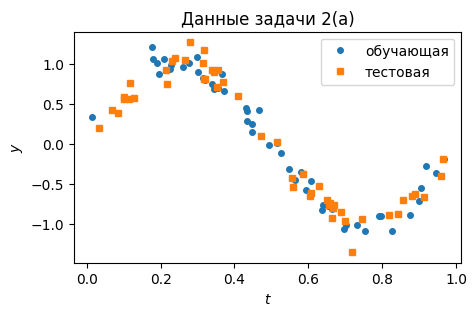

In [2]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

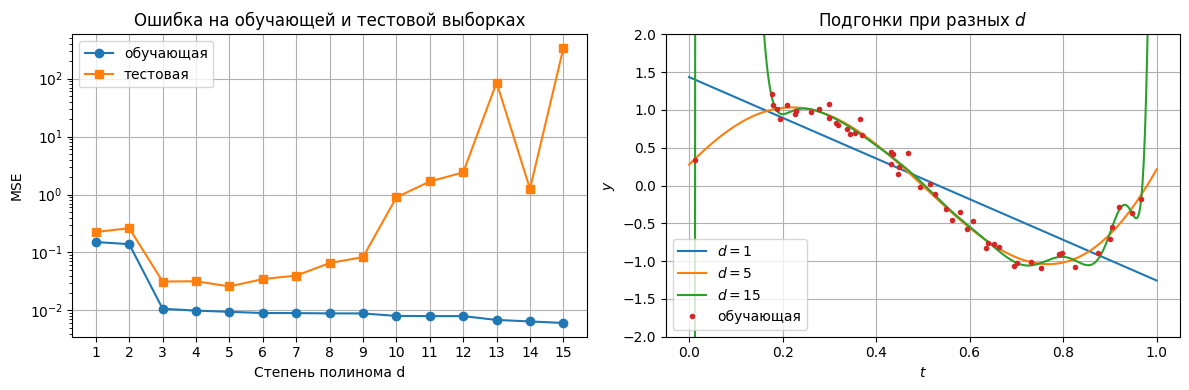

In [12]:
# ваш код
degrees = range(1, 16)

mse_train = []
mse_test = []

for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    x = np.linalg.lstsq(A_train, y_train, rcond=None)[0]

    y_train_pred = A_train @ x

    A_test = np.vander(t_test, d + 1, increasing=True)
    y_test_pred = A_test @ x

    mse_train.append(np.mean((y_train_pred - y_train) ** 2))
    mse_test.append(np.mean((y_test_pred - y_test) ** 2))

grid = np.linspace(0, 1, 400)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# График 1: ошибка
ax[0].semilogy(degrees, mse_train, "o-", label="обучающая")
ax[0].semilogy(degrees, mse_test, "s-", label="тестовая")

ax[0].set_xlabel("Степень полинома d")
ax[0].set_ylabel("MSE")
ax[0].set_xticks(range(1, 16))
ax[0].set_title("Ошибка на обучающей и тестовой выборках")
ax[0].legend()
ax[0].grid()


# График 2: подгонки
for d in [1, 5, 15]:
    A = np.vander(t_train, d + 1, increasing=True)
    x = np.linalg.lstsq(A, y_train, rcond=None)[0]

    A_grid = np.vander(grid, d + 1, increasing=True)
    y_grid = A_grid @ x

    ax[1].plot(grid, y_grid, label=f"$d = {d}$")

ax[1].plot(t_train, y_train, "o", ms=3, label="обучающая")

ax[1].set_ylim(-2, 2)
ax[1].set_xlabel("$t$")
ax[1].set_ylabel("$y$")
ax[1].set_title("Подгонки при разных $d$")
ax[1].legend()
ax[1].grid()


plt.tight_layout()
plt.show()

**Ответ:** Обучающая ошибка монотонно не возрастает, потому что при увеличении степени полинома модель становится более гибкой и может как минимум повторить предыдущую аппроксимацию. Тестовая ошибка немонотонна, потому что при малой степени возникает недообучение, а при слишком большой степени — переобучение на шум обучающих данных.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [13]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [15]:
# ваш код
# Решение исходной задачи
result = linprog(
    c,
    A_ub=-A,
    b_ub=-b,
    bounds=(0, None)
)

x = result.x

print("Оптимальное x =", x)
print("Стоимость =", c @ x)

print("Ax - b =", A @ x - b)
print("Активны Ax >= b:",
      np.isclose(A @ x - b, 0, atol=1e-9))

print("Активны x >= 0:",
      np.isclose(x, 0, atol=1e-9))

Оптимальное x = [ 2.  4. -0.  0.]
Стоимость = 16.0
Ax - b = [0. 0. 0.]
Активны Ax >= b: [ True  True  True]
Активны x >= 0: [False False  True  True]


В исходной задаче оптимум: $x=(2,4,0,0)$, стоимость 16; все три ограничения $Ax\ge b$ и ограничения $x_3\ge0,\ x_4\ge0$ активны.
После увеличения $b_1$ до $11$ получаем $x\approx(1.8889,\,3.5556,\,0,\,0.6667)$, стоимость $\approx17.1111$.
При этом все три ограничения $Ax\ge b$ остаются активными, но среди $x\ge0$ активным остаётся только $x_3=0$; ограничение $x_4\ge0$ перестаёт быть активным.